# Voting System Simulation: STAR + RRV with Tactical Voting and 1% Threshold

- STAR (district) + RRV (national)
- Tactical alignments:
  - Party A voters help Party B
  - Party C & E voters help Party D
- National 1% threshold for party eligibility
- Comparison with FPTP and MMP

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# Parameters
num_districts = 79
num_parties = 6
num_voters = 1000
# num_voters = 10000
# num_voters = 14300940 #2020 election
score_scale = 6
national_seats = num_districts // 2
thresh = 0.02
party_names = [f"Party {chr(65+i)}" for i in range(num_parties)]
print("Number of voters: ", num_voters)
print(party_names)

Number of voters:  1000
['Party A', 'Party B', 'Party C', 'Party D', 'Party E', 'Party F']


In [17]:
# STAR voting (district)
def star_voting_winner(score_df):
    totals = score_df.sum()
    top_two = totals.nlargest(2).index.tolist()
    runoff = score_df[top_two]
    return top_two[np.argmax((runoff[top_two[0]] > runoff[top_two[1]]).sum())]

# Reweighted Range Voting (RRV)
def reweighted_range_voting(score_df, seats):
    weights = np.ones(len(score_df))
    seats_won = pd.Series(0, index=score_df.columns)
    for _ in range(seats):
        weighted_scores = (score_df.T * weights).T
        winner = weighted_scores.sum().idxmax()
        seats_won[winner] += 1
        support = score_df[winner] / score_scale
        weights /= (1 + support)
    return seats_won

In [18]:
# FPTP voting
def fptp_winner(score_df):
    return (score_df == score_scale - 1).sum().idxmax()

In [19]:
# Tactical voting: Even → Party A, Odd → Party B
def tactical_voting(df):
    df = df.copy()
    for i, row in df.iterrows():
        max_party = row.idxmax()
        max_idx = party_names.index(max_party)
        if max_party == "Party A":
            df.at[i, "Party B"] = min(score_scale - 1, df.at[i, "Party B"] + 1)
        elif max_party == "Party B":
            df.at[i, "Party A"] = min(score_scale - 1, df.at[i, "Party A"] + 1)
        elif max_idx >= 2:
            if max_idx % 2 == 0:
                df.at[i, "Party A"] = min(score_scale - 1, df.at[i, "Party A"] + 1)
            else:
                df.at[i, "Party B"] = min(score_scale - 1, df.at[i, "Party B"] + 1)
    return df

In [20]:
# Threshold filtering
def threshold_filter(df, threshold=0.02):
    totals = df.sum()
    share = totals / totals.sum()
    return df[share[share >= threshold].index]

In [21]:
# Generate split block scores
# def generate_block_scores(v, pt, p, dominant, favor_minor=True):
def generate_block_scores(v, pt, dominant, favor_minor=True):
    '''
    Allocated scores to each of parties in pt for v voter, based on party and coalition preference, with probability of p.
    '''
    scores = np.zeros((v, pt), dtype=int)
    # evens = list(range(0, num_parties, 2))
    # odds = list(range(1, num_parties, 2))
    for i in range(v):
        if favor_minor:
            # Voters would score minor parites ahead of major parties in their coalition 
            for j in range(pt):
                if j == 0:
                    scores[i, j] = np.random.choice([0, 1])
                elif j == 1:
                    if scores[i, 0] != 1:
                        scores[i, j] = 1
                    else:
                        scores[i, j] = 0
                elif (j % 2 == 0 and scores[i, 0] == 1):
                    scores[i, j] = np.random.choice([2, 3, 4, 5])
                elif (j % 2 == 1 and scores[i, 1] == 1):
                    scores[i, j] = np.random.choice([2, 3, 4, 5])
                else:
                    scores[i, j] = np.random.choice([0, 1])
        else:
            # Voters would score major parties ahead of minor parties
            for j in range(pt):
                if j == 0:
                    scores[i, j] = np.random.choice([0, 5])
                elif j == 1:
                    if scores[i, 0] != 5:
                        scores[i, j] = 5
                    else:
                        scores[i, j] = 0
                elif (j % 2 == 0 and scores[i, 0] == 5):
                    scores[i, j] = np.random.choice([3, 4])
                elif (j % 2 == 1 and scores[i, 1] == 5):
                    scores[i, j] = np.random.choice([3, 4])
                else:
                    scores[i, j] = np.random.choice([0, 1])
    return scores

def generate_split_voter_blocks(n_voters, dominant, ratio):
    '''
    Split voter block based on the ratio of voters that would score minor parties ahead of major party in the same coalition
    '''
    b1_voters = round(n_voters * ratio)
    b2_voters = n_voters - b1_voters
    block1 = generate_block_scores(b1_voters, num_parties, dominant, favor_minor=True)
    block2 = generate_block_scores(b2_voters, num_parties, dominant, favor_minor=False)
    return np.vstack((block1, block2))

In [22]:
# Soft two-party bias
def generate_scores(n, p, dominant, max_support=0.4, bias_strength=1):
    base = np.random.randint(0, score_scale, (n, p))
    for d in dominant:
        base[:, d] += np.random.binomial(1, max_support, n)
    return np.clip(base, 0, score_scale - 1)

In [23]:
# Generate district and party data
np.random.seed(42)
district_candidates = {
    f"District {i+1}": [f"{party_names[j]} Cand {i+1}" for j in range(num_parties)]
    for i in range(num_districts)
}

party_index = [x for x in range(len(party_names))]
dominant = [0, 1]
dominant_set = set(dominant)  # Type-cast to `set`
minor = [x for x in party_index if x not in dominant]

In [24]:
# Initialize parameters
district_scores = {}
national_scores = []
fptp_district_scores = {}
partylist_scores = {}

# likelyhood of scoring minor parties higher than major parties
# Assumes bi-partisan politics
total_domin_pref = 0.8 
domin_pref = total_domin_pref / len(dominant)
total_minor_pref = (1-total_domin_pref)
minor_pref = total_minor_pref / len(minor)
# ratio of major party voters who would score a minor party higher in the same coalition
domin_star_voter_ratio = 0.15
star_pref = domin_pref * domin_star_voter_ratio + minor_pref * len(minor)
# ratio of major party voters who would still vote for a major party in national party list election
partylist_domin_pref = domin_pref * 0.8
partylist_minor_pref = 1 - partylist_domin_pref
partylist_domin_voters = round(num_voters * partylist_domin_pref)
partylist_minor_voters = num_voters - partylist_domin_voters

print("Max ratio of support for a major party: ", domin_pref)
print("Max ratio of support for a minor party: ", minor_pref)
print("Ratio of dominant party supporters willing to score a minor party ahead in STAR or RRV: ", domin_star_voter_ratio)
print("Ratio of total voters that would score minor party higher in STAR or RRV: ", star_pref)
print("Ratio of dominant party supporters in the FPTP partylist: ", partylist_domin_pref)
print("Ratio of minor party supporters in the FPTP partylist: ", partylist_minor_pref)

Max ratio of support for a major party:  0.4
Max ratio of support for a minor party:  0.04999999999999999
Ratio of dominant party supporters willing to score a minor party ahead in STAR or RRV:  0.15
Ratio of total voters that would score minor party higher in STAR or RRV:  0.25999999999999995
Ratio of dominant party supporters in the FPTP partylist:  0.32000000000000006
Ratio of minor party supporters in the FPTP partylist:  0.6799999999999999


In [25]:
# Generate per district data
for d in district_candidates:
    # STAR, RRV
    district_scores[d] = pd.DataFrame(generate_split_voter_blocks(num_voters, dominant, star_pref), columns=district_candidates[d])
    national_scores.append(generate_split_voter_blocks(num_voters, dominant, star_pref))

    # FPTP, Party List with no scoring/ranking
    fptp_district_scores[d] = pd.DataFrame(generate_scores(num_voters, num_parties, dominant), columns=district_candidates[d])

national_df = pd.DataFrame(np.vstack(national_scores), columns=party_names)
tactical_df = tactical_voting(national_df)
filtered_df = threshold_filter(tactical_df, thresh)

In [26]:
# STAR district winners
district_star = pd.Series(0, index=party_names)
for df in district_scores.values():
    winner = star_voting_winner(df)
    for p in party_names:
        if winner.startswith(p):
            district_star[p] += 1
            break

In [27]:
# Proportional allocations
# rrv = reweighted_range_voting(tactical_df, national_seats)
rrv = reweighted_range_voting(national_df, national_seats)

# Combine for stacked STAR + RRV chart
combined_star_rrv = pd.DataFrame({
    'District (STAR)': district_star,
    'National (RRV)': rrv
}).fillna(0).astype(int)
# total_star_rrv = district_star + rrv

In [29]:
# FPTP district winners
district_fptp = pd.Series(0, index=party_names)
for df in fptp_district_scores.values():
    winner = fptp_winner(df)
    for p in party_names:
        if winner.startswith(p):
            district_fptp[p] += 1
            break

In [31]:
# --- List PR (Largest Remainder Method/Hare Quota) ---
single_choice_votes = []
for _ in range(num_districts):
    # block1 for people who would vote for minor parties in nationa party list election
    # block2 for people who would stick with major parties
    block1_probs = np.array([minor_pref if i in dominant else domin_pref for i in range(num_parties)])
    block1_probs /= block1_probs.sum()
    block2_probs = np.array([domin_pref if i == dominant[0] else domin_pref if i == dominant[1] else minor_pref for i in range(num_parties)])
    block2_probs /= block2_probs.sum()
    choices = np.concatenate([
        np.random.choice(party_names, p=block1_probs, size=partylist_minor_voters),
        np.random.choice(party_names, p=block2_probs, size=partylist_domin_voters)
    ])
    single_choice_votes.extend(choices)

vote_counts = pd.Series(single_choice_votes).value_counts().reindex(party_names, fill_value=0)
total_valid_votes = vote_counts.sum()
vote_share = vote_counts / total_valid_votes
eligible_parties = vote_share[vote_share >= 0.01]
eligible_votes = vote_counts[eligible_parties.index]

quota = eligible_votes.sum() / national_seats
initial_seats = (eligible_votes // quota).astype(int)
remainders = eligible_votes % quota
seats_to_allocate = national_seats - initial_seats.sum()
remainder_winners = remainders.sort_values(ascending=False).head(seats_to_allocate).index
lrm_additional = pd.Series(0, index=party_names)
lrm_additional[remainder_winners] = 1
hare_quota_seats = initial_seats.reindex(party_names, fill_value=0) + lrm_additional

In [30]:
# MMP results 
ideal = filtered_df.sum()
ideal = ideal / ideal.sum() * num_districts
ideal = ideal.round()

mmp_topup = ideal - district_fptp[ideal.index]
mmp_topup[mmp_topup < 0] = 0
total_mmp = district_fptp.copy()
total_mmp.update(district_fptp[ideal.index] + mmp_topup)

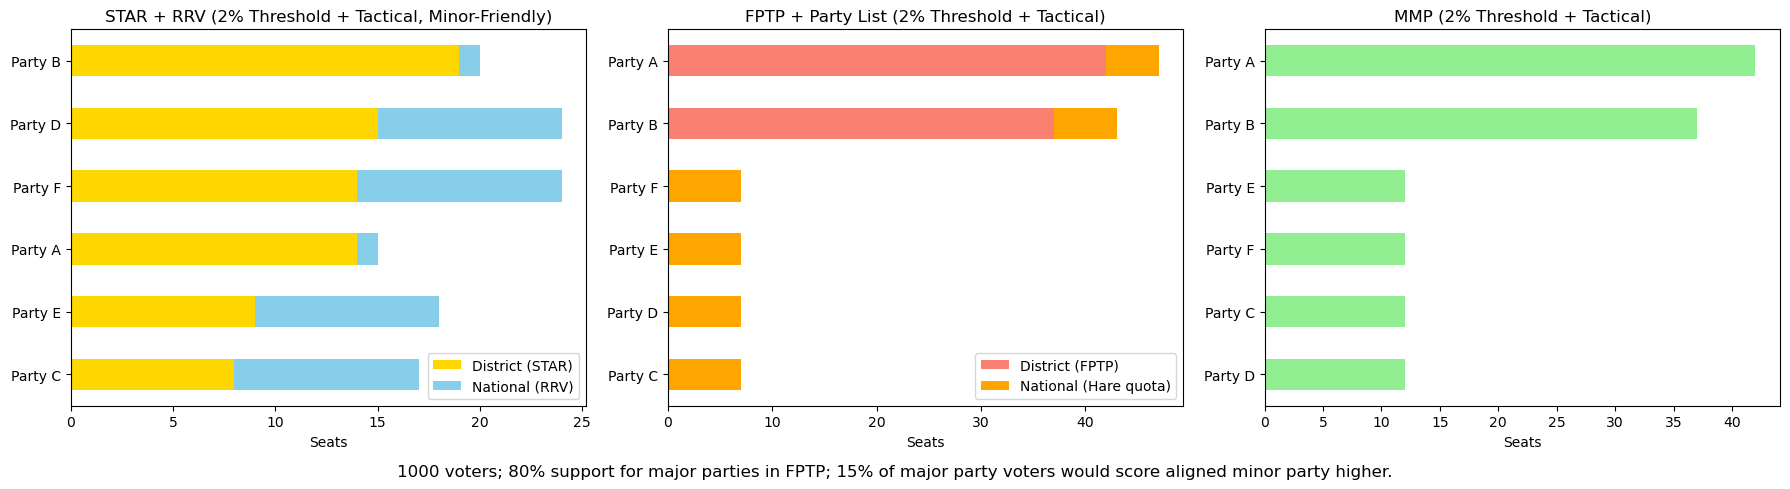

In [32]:
# Plotting
th_int = str(int(thresh*100))
star_title = "STAR + RRV (" + th_int + "% Threshold + Tactical, Minor-Friendly)"
fptp_title = "FPTP + Party List (" + th_int + "% Threshold + Tactical)"
mmp_title = "MMP (" + th_int + "% Threshold + Tactical)"
tdp_int = str(int(total_domin_pref*100))
ds_int = str(int(domin_star_voter_ratio *100))
chart_title = str(num_voters) + " voters; " + tdp_int + "% support for major parties in FPTP; " + ds_int + "% of major party voters would score aligned minor party higher." 
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# total_star_rrv.sort_values().plot(kind='barh', ax=ax[0], color='skyblue')

combined_star_rrv.sort_values(by=["District (STAR)", "National (RRV)"], ascending=True).plot(
    kind='barh', stacked=True, ax=ax[0], color=['gold', 'skyblue']
)

ax[0].legend( loc = 'lower right')
ax[0].set_title(star_title)
ax[0].set_xlabel("Seats")

# district_fptp.sort_values().plot(kind='barh', ax=ax[1], color='salmon')
# Combine for stacked FPTP + Hare Quata chart
combined_fptp_harelist = pd.DataFrame({
    'District (FPTP)': district_fptp,
    'National (Hare quota)': hare_quota_seats
}).fillna(0).astype(int)

combined_fptp_harelist.sort_values(by=["District (FPTP)", "National (Hare quota)"], ascending=True).plot(
    kind='barh', stacked=True, ax=ax[1], color=['salmon', 'orange']
)

ax[1].legend( loc = 'lower right')
ax[1].set_title(fptp_title)
ax[1].set_xlabel("Seats")

total_mmp.sort_values().plot(kind='barh', ax=ax[2], color='lightgreen')
ax[2].set_title(mmp_title)
ax[2].set_xlabel("Seats")

my_suptitle = plt.suptitle(chart_title, y = 0.0)

plt.tight_layout()
plt.savefig("result.png", bbox_inches='tight', bbox_extra_artists=[my_suptitle])
plt.show()

In [33]:
print("total STAR + RRV seats: ", district_star.sum() + rrv.sum())
print("total FPTP seats: ", district_fptp.sum() + hare_quota_seats.sum())
print("total MMP seats: ", total_mmp.sum())

total STAR + RRV seats:  118
total FPTP seats:  118
total MMP seats:  127


In [46]:
# spath = 'results/'+str(num_voters)+'_'+str(num_districts)+'_'+str(national_seats)+'_'+str(num_parties)+'_'+str(domin_pref)+'_'+str(domin_star_voter_ratio)
# os.makedirs(spath, exist_ok=True)
# # STAR district scores
# for df_name, df in district_scores.items():
#     filename = f"{spath}/star_{df_name}.csv"
#     df.to_csv(filename, index=False)
#     # print(f"DataFrame '{df_name}' saved to '{filename}'")
# national_df.to_csv(spath+'/rrv_ballots.csv', index=False)
#     
# # FPTP district scores
# for df_name, df in fptp_district_scores.items():
#     filename = f"{spath}/fptp_{df_name}.csv"
#     df.to_csv(filename, index=False)
#     # print(f"DataFrame '{df_name}' saved to '{filename}'")
# # FPTP Party list votes 
# np.savetxt(spath+'/fptp_partylist.csv', single_choice_votes, fmt="%s", delimiter=",")